# Final Evaluation: MS MARCO with BM25, BERT, Word2Vec, FAISS, and HNSW

This notebook evaluates retrieval on the **exact dataset configuration used by your friend's code**:
- Dataset: `ms_marco`, config `v1.1`
- Split: `train[:3900]`

Retrieval methods compared:
- BM25 (lexical baseline)
- BERT + FAISS
- BERT + custom HNSW (`hnsw_index`)
- Word2Vec + FAISS
- Word2Vec + custom HNSW (`hnsw_index`)

Metrics: Precision@10, Recall@10, and latency (ms/query).

In [12]:
import os
import time
import string
import random
import subprocess
import sys
import numpy as np
import pandas as pd
import torch
import faiss
import nltk
from tqdm.notebook import tqdm

for pkg in ["datasets", "sentence-transformers", "gensim", "rank-bm25"]:
    try:
        __import__(pkg.replace("-", "_"))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from gensim.models import Word2Vec
from rank_bm25 import BM25Okapi
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

sys.path.insert(0, r"C:\Users\Chaitanya's Laptop\Desktop\Data_Science\my_algos")
import hnsw_index

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

K = 10
MSMARCO_SUBSET = 3900
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("hnsw_index loaded:", hnsw_index)

Device: cuda
hnsw_index loaded: <module 'hnsw_index' from "C:\\Users\\Chaitanya's Laptop\\Desktop\\Data_Science\\my_algos\\hnsw_index.cp310-win_amd64.pyd">


In [13]:
dataset = load_dataset("ms_marco", "v1.1", split=f"train[:{MSMARCO_SUBSET}]")

doc_to_id = {}
documents_text = []
query_records = []

for item in tqdm(dataset, desc="Preparing MS MARCO"):
    query_text = (item.get("query") or "").strip()
    passages = item["passages"]["passage_text"]
    labels = item["passages"]["is_selected"]

    relevant_ids = set()
    for passage, label in zip(passages, labels):
        text = (passage or "").strip()
        if not text:
            continue

        doc_id = doc_to_id.get(text)
        if doc_id is None:
            doc_id = len(documents_text)
            doc_to_id[text] = doc_id
            documents_text.append(text)

        if int(label) == 1:
            relevant_ids.add(doc_id)

    query_records.append({
        "query": query_text,
        "relevant_ids": sorted(relevant_ids),
    })

document_ids = list(range(len(documents_text)))
queries_dict = {i: rec["query"] for i, rec in enumerate(query_records)}
qrels_dict = {
    i: {doc_id: 1 for doc_id in rec["relevant_ids"]}
    for i, rec in enumerate(query_records)
    if rec["relevant_ids"]
}

print(f"MS MARCO subset rows: {len(dataset):,}")
print(f"Unique documents: {len(document_ids):,}")
print(f"Queries: {len(queries_dict):,}")
print(f"Queries with relevance labels: {len(qrels_dict):,}")

v1.1/validation-00000-of-00001.parquet:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

v1.1/train-00000-of-00001.parquet:   0%|          | 0.00/175M [00:00<?, ?B/s]

v1.1/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10047 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/82326 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9650 [00:00<?, ? examples/s]

Preparing MS MARCO:   0%|          | 0/3900 [00:00<?, ?it/s]

MS MARCO subset rows: 3,900
Unique documents: 31,920
Queries: 3,900
Queries with relevance labels: 3,787


In [14]:
def evaluate(search_fn, queries_dict, qrels_dict, k=10, desc=""):
    total_p = 0.0
    total_r = 0.0
    valid = 0
    t0 = time.perf_counter()

    for qid, qtext in tqdm(queries_dict.items(), desc=desc or f"Eval@{k}"):
        if qid not in qrels_dict:
            continue
        relevant = set(qrels_dict[qid].keys())
        if not relevant:
            continue

        valid += 1
        retrieved = search_fn(qtext, k)
        hits = sum(1 for d in retrieved if d in relevant)

        total_p += hits / k
        total_r += hits / len(relevant)

    elapsed_ms = (time.perf_counter() - t0) * 1000 / max(valid, 1)
    return {
        "precision_at_k": total_p / max(valid, 1),
        "recall_at_k": total_r / max(valid, 1),
        "ms_per_query": elapsed_ms,
        "valid_queries": valid,
    }

In [15]:
BERT_EMB_PATH = "bert_embeddings.npy"
bert_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

need_rebuild_bert = True
if os.path.exists(BERT_EMB_PATH):
    cached = np.load(BERT_EMB_PATH).astype("float32")
    if cached.ndim == 2 and cached.shape[0] == len(documents_text):
        bert_embeddings = cached
        need_rebuild_bert = False
        print("Loaded cached BERT embeddings")

if need_rebuild_bert:
    print("Generating BERT embeddings...")
    bert_embeddings = bert_model.encode(
        documents_text,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")
    np.save(BERT_EMB_PATH, bert_embeddings)

norms = np.linalg.norm(bert_embeddings, axis=1, keepdims=True)
bert_embeddings /= np.where(norms == 0, 1, norms)
print("BERT embeddings:", bert_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating BERT embeddings...


Batches:   0%|          | 0/499 [00:00<?, ?it/s]

BERT embeddings: (31920, 384)


In [16]:
# Build BERT FAISS (exact cosine via inner product on normalized vectors)
bert_dim = bert_embeddings.shape[1]
bert_faiss = faiss.IndexFlatIP(bert_dim)
bert_faiss.add(bert_embeddings)

# Build BERT custom HNSW
BERT_M = 16
BERT_EFC = 200
BERT_EF = 50
bert_hnsw = hnsw_index.HNSWIndex(BERT_M, BERT_EFC, SEED)
bert_hnsw.insert_batch(bert_embeddings)

def search_bert_faiss(query_text, k=10):
    q = bert_model.encode([query_text], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores, idx = bert_faiss.search(q, k)
    return [document_ids[i] for i in idx[0]]

def search_bert_hnsw(query_text, k=10):
    q = bert_model.encode([query_text], convert_to_numpy=True, normalize_embeddings=True).astype("float32")[0]
    _, idx = bert_hnsw.search(q, k, ef=max(BERT_EF, k))
    return [document_ids[i] for i in idx]

In [17]:
W2V_EMB_PATH = "w2v_embeddings.npy"
W2V_MODEL_PATH = "w2v_model.bin"
stop_words = set(stopwords.words("english"))

def tokenize(text):
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    return [w for w in word_tokenize(text) if w not in stop_words]

def doc_vector(model, tokens):
    valid = [w for w in tokens if w in model.wv.key_to_index]
    return np.mean(model.wv[valid], axis=0) if valid else np.zeros(model.vector_size, dtype=np.float32)

tokenized_docs = [tokenize(t) for t in tqdm(documents_text, desc="Tokenize docs")]

need_rebuild_w2v = True
if os.path.exists(W2V_EMB_PATH) and os.path.exists(W2V_MODEL_PATH):
    cached_emb = np.load(W2V_EMB_PATH).astype("float32")
    cached_model = Word2Vec.load(W2V_MODEL_PATH)
    if cached_emb.ndim == 2 and cached_emb.shape[0] == len(documents_text):
        w2v_embeddings = cached_emb
        w2v_model = cached_model
        need_rebuild_w2v = False
        print("Loaded cached Word2Vec artifacts")

if need_rebuild_w2v:
    print("Training Word2Vec and generating embeddings...")
    w2v_model = Word2Vec(
        sentences=tokenized_docs,
        vector_size=300,
        window=5,
        min_count=2,
        workers=4,
        seed=SEED
    )
    w2v_model.save(W2V_MODEL_PATH)

    w2v_embeddings = np.array([doc_vector(w2v_model, tok) for tok in tokenized_docs], dtype="float32")
    np.save(W2V_EMB_PATH, w2v_embeddings)

norms = np.linalg.norm(w2v_embeddings, axis=1, keepdims=True)
w2v_embeddings /= np.where(norms == 0, 1, norms)

bm25 = BM25Okapi(tokenized_docs)
print("Word2Vec embeddings:", w2v_embeddings.shape)

Tokenize docs:   0%|          | 0/31920 [00:00<?, ?it/s]

Training Word2Vec and generating embeddings...
Word2Vec embeddings: (31920, 300)


In [18]:
# Build Word2Vec FAISS
w2v_dim = w2v_embeddings.shape[1]
w2v_faiss = faiss.IndexFlatIP(w2v_dim)
w2v_faiss.add(w2v_embeddings)

# Build Word2Vec custom HNSW
W2V_M = 16
W2V_EFC = 200
W2V_EF = 50
w2v_hnsw = hnsw_index.HNSWIndex(W2V_M, W2V_EFC, SEED)
w2v_hnsw.insert_batch(w2v_embeddings)

def search_w2v_faiss(query_text, k=10):
    q = doc_vector(w2v_model, tokenize(query_text)).astype("float32")
    n = np.linalg.norm(q)
    if n > 0:
        q /= n
    scores, idx = w2v_faiss.search(q.reshape(1, -1), k)
    return [document_ids[i] for i in idx[0]]

def search_w2v_hnsw(query_text, k=10):
    q = doc_vector(w2v_model, tokenize(query_text)).astype("float32")
    n = np.linalg.norm(q)
    if n > 0:
        q /= n
    _, idx = w2v_hnsw.search(q, k, ef=max(W2V_EF, k))
    return [document_ids[i] for i in idx]

def search_bm25(query_text, k=10):
    q_tok = tokenize(query_text)
    scores = np.array(bm25.get_scores(q_tok), dtype=np.float32)
    top_idx = np.argpartition(scores, -k)[-k:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return [document_ids[i] for i in top_idx]

In [19]:
methods = {
    "BM25": search_bm25,
    "BERT + FAISS": search_bert_faiss,
    "BERT + HNSW": search_bert_hnsw,
    "Word2Vec + FAISS": search_w2v_faiss,
    "Word2Vec + HNSW": search_w2v_hnsw,
}

results = []
for name, fn in methods.items():
    m = evaluate(fn, queries_dict, qrels_dict, k=K, desc=name)
    results.append({
        "Method": name,
        "Precision@10": m["precision_at_k"],
        "Recall@10": m["recall_at_k"],
        "ms/query": m["ms_per_query"],
        "ValidQueries": m["valid_queries"],
    })

df_results = pd.DataFrame(results).sort_values(["Recall@10", "Precision@10"], ascending=False)
df_results

BM25:   0%|          | 0/3900 [00:00<?, ?it/s]

BERT + FAISS:   0%|          | 0/3900 [00:00<?, ?it/s]

BERT + HNSW:   0%|          | 0/3900 [00:00<?, ?it/s]

Word2Vec + FAISS:   0%|          | 0/3900 [00:00<?, ?it/s]

Word2Vec + HNSW:   0%|          | 0/3900 [00:00<?, ?it/s]

,Method,Precision@10,Recall@10,ms/query,ValidQueries
1,BERT + FAISS,0.106786,0.957329,8.422028,3787
2,BERT + HNSW,0.106786,0.957329,5.702118,3787
0,BM25,0.090996,0.813981,20.522392,3787
3,Word2Vec + FAISS,0.010721,0.094565,1.904041,3787
4,Word2Vec + HNSW,0.010721,0.094565,0.303370,3787


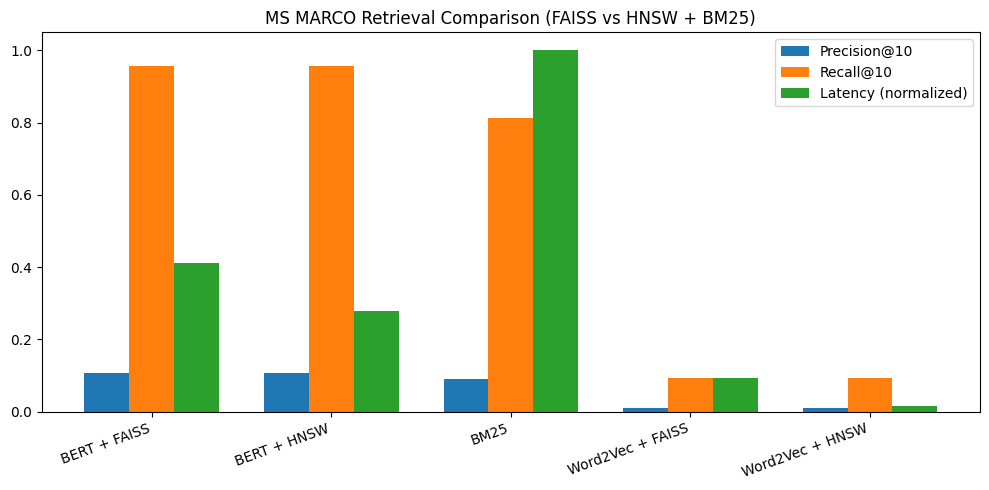

Saved final_eval_results.csv


In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
x = np.arange(len(df_results))
w = 0.25

plt.bar(x - w, df_results["Precision@10"], width=w, label="Precision@10")
plt.bar(x, df_results["Recall@10"], width=w, label="Recall@10")
plt.bar(x + w, df_results["ms/query"] / max(df_results["ms/query"]), width=w, label="Latency (normalized)")

plt.xticks(x, df_results["Method"], rotation=20, ha="right")
plt.title("MS MARCO Retrieval Comparison (FAISS vs HNSW + BM25)")
plt.legend()
plt.tight_layout()
plt.show()

df_results.to_csv("final_eval_results.csv", index=False)
print("Saved final_eval_results.csv")